In [1]:
import os
import sys
import numpy as np

root_path = os.path.abspath(os.path.join('..'))
if root_path not in sys.path:
    sys.path.append(root_path)
 
from syn_project.utils_train import *
from syn_project.utils_color_analysis import *
from syn_project.utils_notebook import *

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler

%matplotlib widget

In [2]:
project_name = "syn"
condition = "basic"
data = "biased_00"
switch_epoch = 0
checkpoint_epoch = 0

n_samples_test = 1000

experiment_name = get_experiment_name(condition, data, switch_epoch)
cat_names=CAT_NAMES

training_params = get_training_params(project_name, experiment_name)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

global_workspace = get_global_workspace(project_name, experiment_name, epoch=checkpoint_epoch)
data_module = get_data_module(project_name,  experiment_name)
test_samples = get_data_samples(data_module, n_samples_test, split= "test")
data_translated = get_data_translated(global_workspace, test_samples, n_samples_test)

data_dir = f"{ROOT_PATH}/checkpoints/{project_name}/{experiment_name}/checkpoints"
files = load_epoch_files(data_dir)
epochs, color_history = get_color_data_from_epoch_files(files)


/home/lucas/.cache/pypoetry/virtualenvs/alexis-n7zQ69N0-py3.11/lib/python3.11/site-packages/lightning/fabric/utilities/cloud_io.py:73: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


Loading model from checkpoint: /home/lucas/gwsyn/checkpoints/syn/basic_biased_00/checkpoints/last.ckpt
Loaded default weights from /home/lucas/gwsyn/checkpoints/syn/basic_biased_00/checkpoints/last.ckpt


In [3]:
plt.figure()
plt.close()

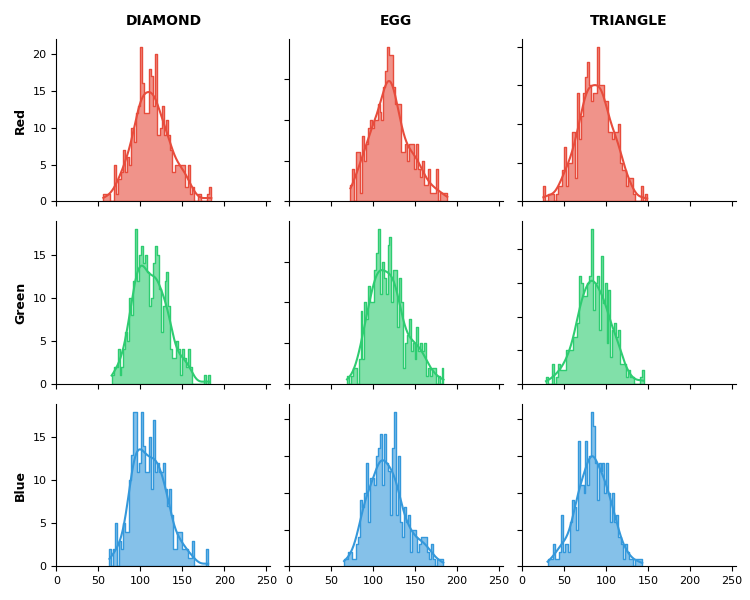

In [4]:
plot_type = "decoded_edge"

colors_np = get_samples_rgb(data_translated, plot_type)
categories_indices_train = get_categories_indices(data_translated, 'train_attr')
categories_indices_decoded = get_categories_indices(data_translated, 'attr_decoded')

fig = plot_rgb_distribution(colors_np, categories_indices_decoded, n_bins=50)
plt.show()


In [5]:
# nombre de classifications fausses
len(categories_indices_decoded == categories_indices_train) - n_samples_test

0

In [6]:
# est ce qu'on peut reconnaitre la catégorie avec seulement la couleur de l'espace latent attribut?
scaler = StandardScaler()
model = LogisticRegression(max_iter=1000)

X = colors_np 
y = categories_indices_train

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

print(f"Précision globale (Accuracy) : {accuracy_score(y_test, y_pred):.2%}")
print("\nDétails par catégorie :")
print(classification_report(y_test, y_pred))

Précision globale (Accuracy) : 54.00%

Détails par catégorie :
              precision    recall  f1-score   support

           0       0.34      0.21      0.26        61
           1       0.49      0.59      0.54        69
           2       0.68      0.77      0.72        70

    accuracy                           0.54       200
   macro avg       0.51      0.53      0.51       200
weighted avg       0.51      0.54      0.52       200



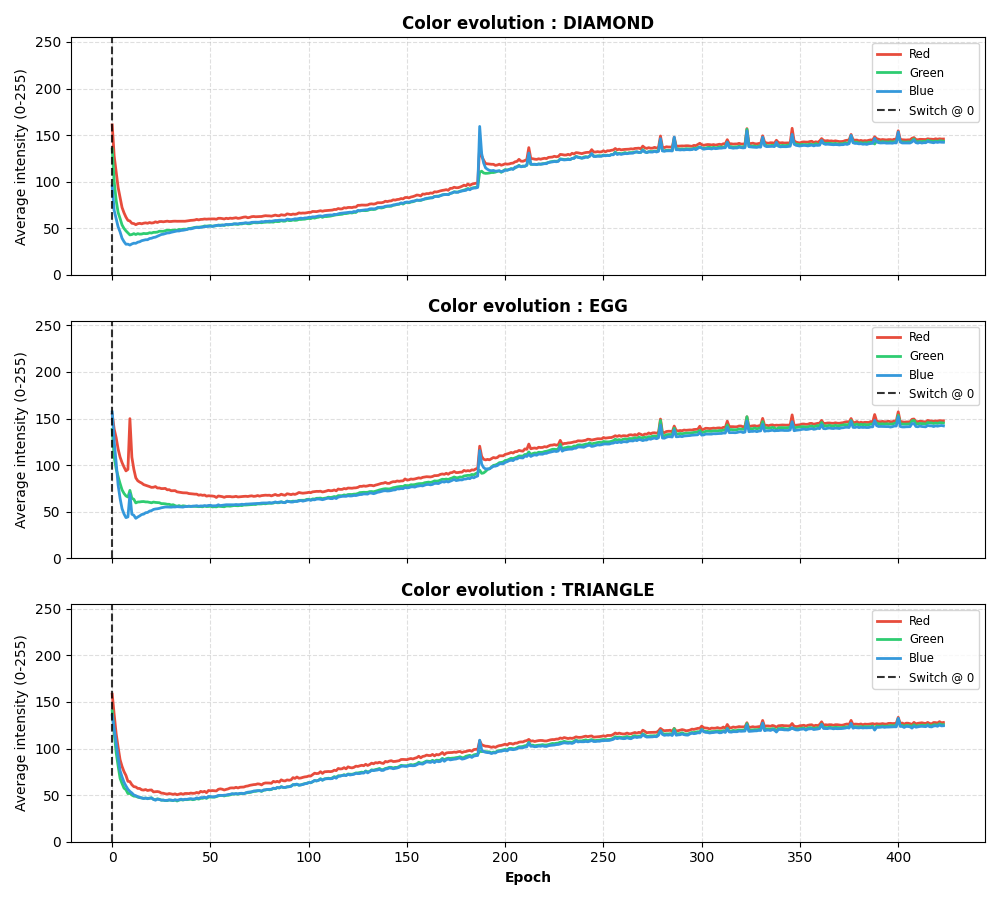

In [7]:
# attention, utilise les fichiers stockés par epoch, pour l'instant 
fig = plot_color_evolution_per_category(data_dir, CAT_NAMES, vline_epoch=0)
plt.show()


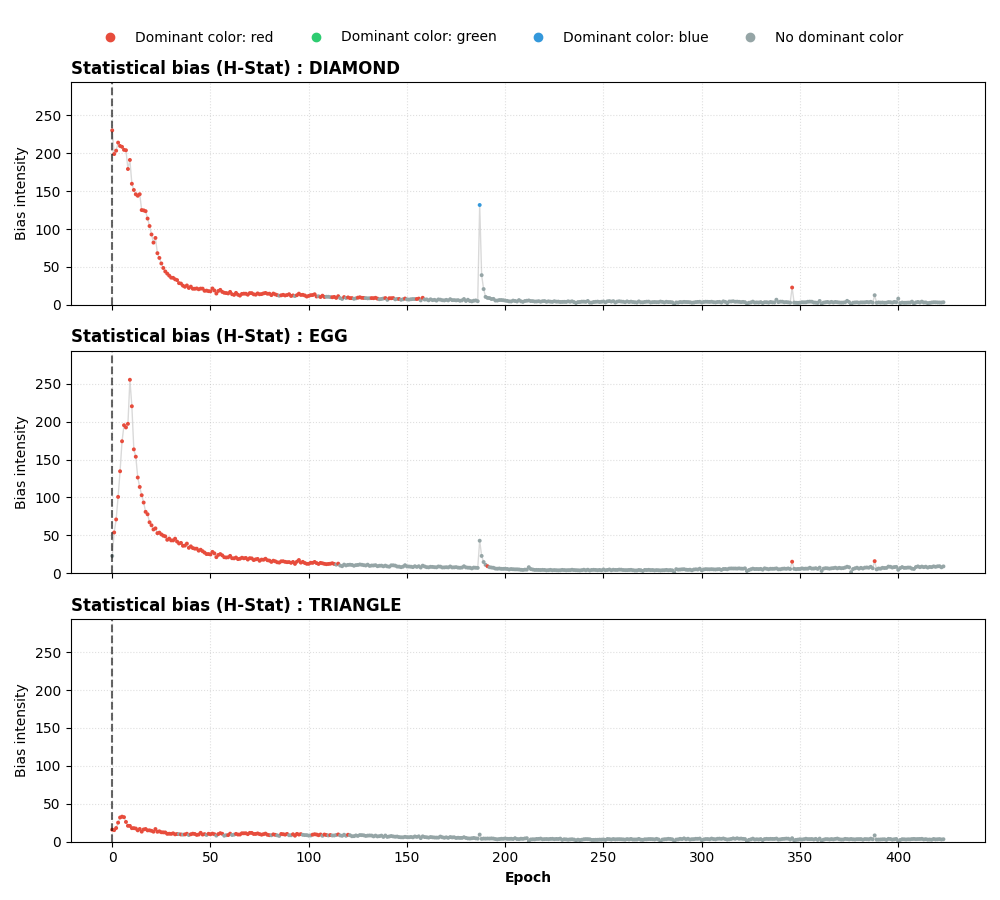

In [8]:
color_statisitical_dominance = color_statisitical_dominance_analysis(data_dir)
fig = plot_statistical_dominance_evolution(color_statisitical_dominance, cat_names=cat_names, vline_epoch=0)

plt.show()

In [9]:
import os
import re
from IPython.display import display, Image
import ipywidgets as widgets

def interactive_epoch_viewer(data_dir: str):
    # 1. Récupération et tri des fichiers par numéro d'époque
    files = [f for f in os.listdir(data_dir) if f.startswith("fig_comparison_epoch_") and f.endswith(".png")]
    
    # Extraction du numéro d'époque pour un tri numérique correct
    def extract_epoch(filename: str) -> int:
        # On utilise \d+ pour capturer les chiffres (digits)
        match = re.search(r'epoch_(\d+)', filename)
        return int(match.group(1)) if match else 0

    files.sort(key=extract_epoch)
    epochs = [extract_epoch(f) for f in files]

    if not files:
        print("Aucune image trouvée dans le dossier.")
        return

    # 2. Création du widget Slider
    slider = widgets.IntSlider(
        value=epochs[0],
        min=min(epochs),
        max=max(epochs),
        step=epochs[1] - epochs[0] if len(epochs) > 1 else 1,
        description='Epoch:',
        layout=widgets.Layout(width='80%'),
        continuous_update=False  # Évite de charger toutes les images pendant qu'on glisse
    )

    # 3. Fonction d'affichage
    def update_display(epoch):
        filename = f"fig_comparison_epoch_{epoch:03d}.png"
        filepath = os.path.join(data_dir, filename)
        
        if os.path.exists(filepath):
            display(Image(filename=filepath))
        else:
            print(f"Image pour l'époque {epoch} non trouvée.")

    # 4. Connexion du slider à la fonction
    widgets.interact(update_display, epoch=slider)

# --- Utilisation ---
interactive_epoch_viewer(data_dir + "/visual_logs")

interactive(children=(IntSlider(value=0, continuous_update=False, description='Epoch:', layout=Layout(width='8…

In [10]:
# je veux comparer attributs et espace latent
attribut = test_samples[frozenset(["v_latents", "attr"])]["attr"]
unimodal_latents = global_workspace.encode_domains(test_samples)
gw_latents = global_workspace.encode(unimodal_latents)

espace_latent_attr = gw_latents[frozenset({'attr','v_latents'})]['attr']

In [11]:
original_attr = torch.cat((attribut[0], attribut[1]), dim=1)
# colors_torch = torch.from_numpy(colors_np).to(device)
# a = torch.cat((original_attr, colors_torch), dim=1)

In [12]:
import pandas as pd

# 1. Conversion en DataFrame (on repasse sur CPU si besoin)
df1 = pd.DataFrame(original_attr.cpu().numpy()) # (N, 8)
df2 = pd.DataFrame(espace_latent_attr.detach().cpu().numpy()) # (N, 12)

# 2. Calcul de la corrélation croisée
corr_matrix = df1.corrwith(df2, axis=0) # Attention: corrwith compare ligne à ligne ou colonne à colonne

# Pour avoir la matrice complète (chaque colonne de t1 vs chaque colonne de t2) :
full_corr = pd.concat([df1, df2], axis=1).corr().iloc[:8, 8:]

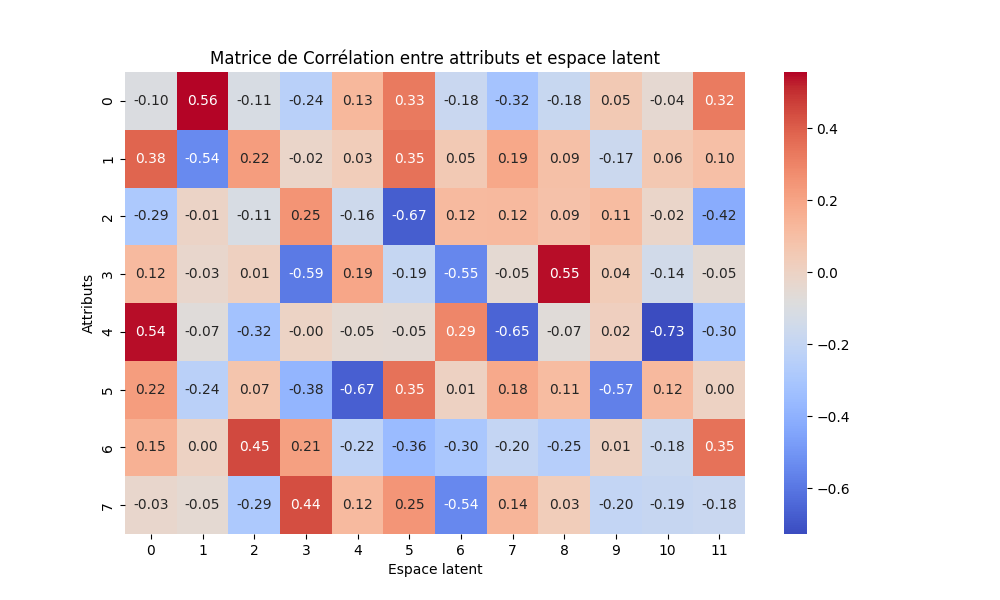

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.heatmap(full_corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.xlabel('Espace latent')
plt.ylabel('Attributs')
plt.title('Matrice de Corrélation entre attributs et espace latent')
plt.show()

In [15]:
# une matrice de corrélation entre les attributs et le rgb du global workspace

import pandas as pd

# 1. Conversion en DataFrame (on repasse sur CPU si besoin)
df1 = pd.DataFrame(original_attr.cpu().numpy()) # (N, 8)
df2 = pd.DataFrame(colors_np) # (N, 3)

# 2. Calcul de la corrélation croisée
corr_matrix = df1.corrwith(df2, axis=0) # Attention: corrwith compare ligne à ligne ou colonne à colonne

# Pour avoir la matrice complète (chaque colonne de t1 vs chaque colonne de t2) :
full_corr = pd.concat([df1, df2], axis=1).corr().iloc[:8, 8:]


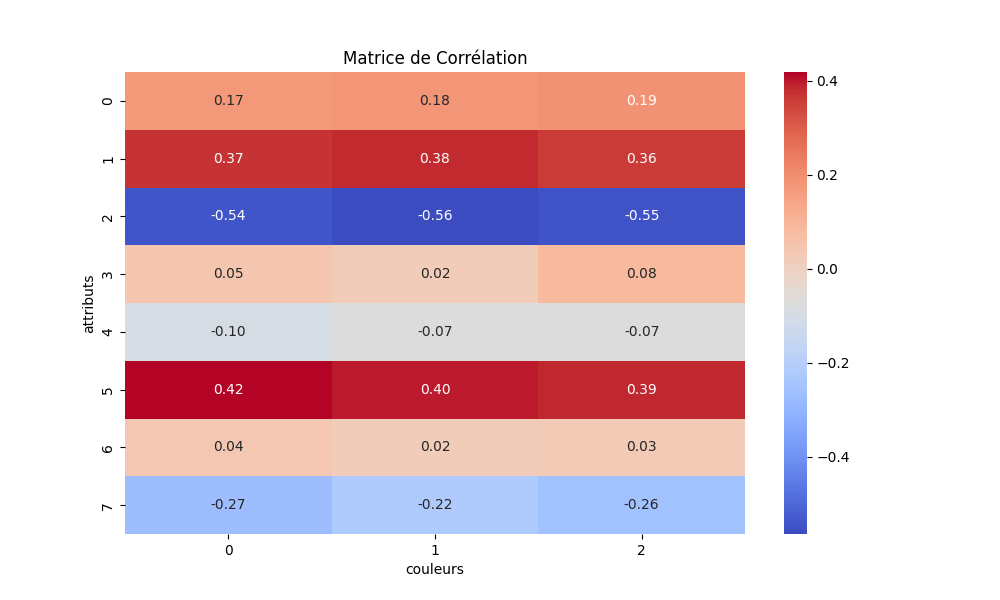

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.heatmap(full_corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.xlabel('couleurs')
plt.ylabel('attributs')
plt.title('Matrice de Corrélation')
plt.show()

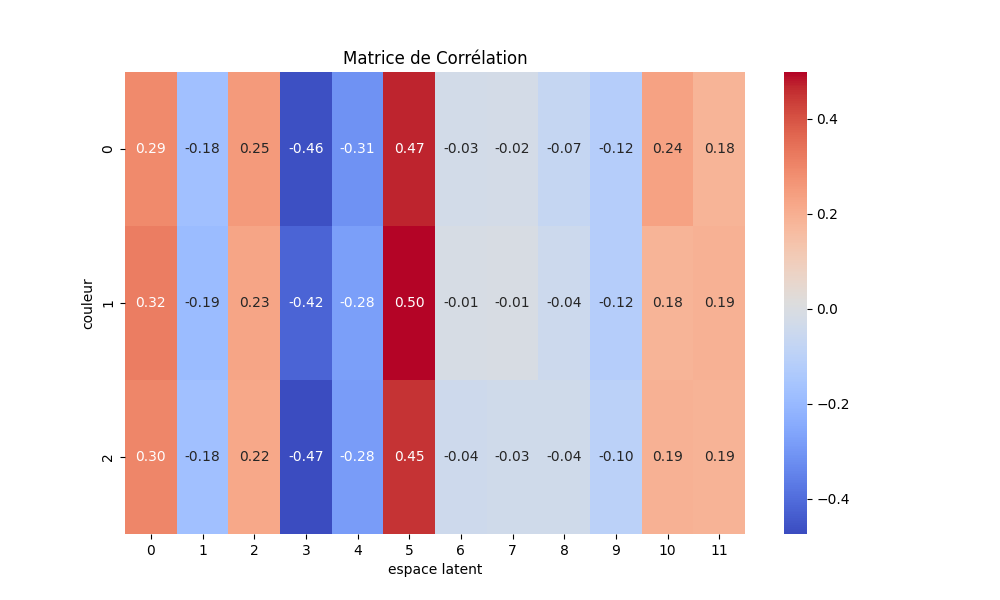

In [17]:
# matrice de corrélation entre couleur et espace latent

import pandas as pd

# 1. Conversion en DataFrame (on repasse sur CPU si besoin)
df1 = pd.DataFrame(colors_np) # (N, 3)
df2 = pd.DataFrame(espace_latent_attr.detach().cpu().numpy()) # (N, 12)

# 2. Calcul de la corrélation croisée
corr_matrix = df1.corrwith(df2, axis=0) # Attention: corrwith compare ligne à ligne ou colonne à colonne

# Pour avoir la matrice complète (chaque colonne de t1 vs chaque colonne de t2) :
full_corr = pd.concat([df1, df2], axis=1).corr().iloc[:3,3:]


plt.figure(figsize=(10, 6))
sns.heatmap(full_corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.xlabel('espace latent')
plt.ylabel('couleur')
plt.title('Matrice de Corrélation')
plt.show()
